<a href="https://colab.research.google.com/github/min0left-hub/mobis_ai_education_2026/blob/main/DL_03_CNN_C_IMPELLER_ANOMALY_DETECTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# !pip install -q --upgrade gdown

# Casting Impeller Defect Detection CNN + Hyperparameter Search Template

이 노트북은 Colab에서 `data/casting_data/casting_data` 아래의 주조품 이미지 데이터를 사용해 **정상(ok_front) / 비정상(def_front)** 이진 분류 CNN을 학습합니다.

폴더 구조는 아래와 같이 가정합니다.

```text
data/casting_data/casting_data/
├── train/
│   ├── ok_front/
│   └── def_front/
└── test/
    ├── ok_front/
    └── def_front/
```

사용 방식:
1. 데이터 경로가 맞는지 확인
2. `SEARCH_SPACE`에 하이퍼파라미터 조합을 여러 개 정의
3. `CASE_IDX`를 바꿔가며 **한 번에 1조합씩** 학습
4. 결과는 `search_results.csv`에 누적 저장

In [2]:
!pip install -q --upgrade gdown

file_id = "1Cy4ZEaG_vcJN3ZEaYDlcPDjdO8TkmSsl"

!gdown https://drive.google.com/uc?id={file_id} -O archive.zip

Downloading...
From (original): https://drive.google.com/uc?id=1Cy4ZEaG_vcJN3ZEaYDlcPDjdO8TkmSsl
From (redirected): https://drive.google.com/uc?id=1Cy4ZEaG_vcJN3ZEaYDlcPDjdO8TkmSsl&confirm=t&uuid=7d698ad6-f3d8-42ac-af61-afcbafab185b
To: /content/archive.zip
100% 105M/105M [00:00<00:00, 121MB/s] 


In [3]:
!ls -lh archive.zip
!unzip -q archive.zip -d data
!ls data

-rw------- 1 root root 101M May  6 09:34 archive.zip
casting_512x512  casting_data


In [4]:
# 필요 라이브러리
import os
import random
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [5]:
# 재현성을 위한 seed 고정
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Colab GPU 확인
print("GPU available:", tf.config.list_physical_devices('GPU'))

GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. 데이터 경로 확인

네가 말한 경로를 기본값으로 설정했습니다. 데이터가 정상적으로 풀렸다면 아래 셀에서 train/test 폴더와 클래스 폴더가 보여야 합니다.

In [6]:
BASE_DIR = Path("data/casting_data/casting_data")
TRAIN_DIR = BASE_DIR / "train"
TEST_DIR = BASE_DIR / "test"

print("BASE_DIR exists:", BASE_DIR.exists(), BASE_DIR)
print("TRAIN_DIR exists:", TRAIN_DIR.exists(), TRAIN_DIR)
print("TEST_DIR exists:", TEST_DIR.exists(), TEST_DIR)

for split_dir in [TRAIN_DIR, TEST_DIR]:
    print("", split_dir)
    if split_dir.exists():
        for cls in sorted(os.listdir(split_dir)):
            cls_path = split_dir / cls
            if cls_path.is_dir():
                n_files = len(list(cls_path.glob("*")))
                print(f"  {cls}: {n_files} files")

BASE_DIR exists: True data/casting_data/casting_data
TRAIN_DIR exists: True data/casting_data/casting_data/train
TEST_DIR exists: True data/casting_data/casting_data/test
 data/casting_data/casting_data/train
  def_front: 3758 files
  ok_front: 2875 files
 data/casting_data/casting_data/test
  def_front: 453 files
  ok_front: 262 files


## 2. 하이퍼파라미터 조합 정의

아래 `SEARCH_SPACE`에 여러 조합을 넣어두고, `CASE_IDX`만 바꿔서 실행하면 됩니다.  
즉, 이 노트북은 **하이퍼파라미터 1조합씩 학습하고 결과를 누적 저장**하는 방식입니다.

In [7]:
SEARCH_SPACE = [
    {
        "case_name": "case_001_baseline",
        "img_size": 244,
        "batch_size": 32,
        "conv_filters": [16, 32, 64, 128],
        "kernel_size": 3,
        "dense_units": 64,
        "dropout": 0.2,
        "learning_rate": 1e-3,
        "optimizer": "adam",
        "epochs": 10,
        "use_batchnorm": False,
        "augmentation": True,
    },
    {
        "case_name": "case_002_deeper_bn",
        "img_size": 244,
        "batch_size": 32,
        "conv_filters": [16, 32, 64, 128, 256],
        "kernel_size": 3,
        "dense_units": 128,
        "dropout": 0.3,
        "learning_rate": 5e-4,
        "optimizer": "adam",
        "epochs": 10,
        "use_batchnorm": True,
        "augmentation": True,
    },
    {
        "case_name": "case_003_smaller_lr",
        "img_size": 224,
        "batch_size": 16,
        "conv_filters": [32, 64, 128],
        "kernel_size": 3,
        "dense_units": 128,
        "dropout": 0.4,
        "learning_rate": 1e-4,
        "optimizer": "adam",
        "epochs": 15,
        "use_batchnorm": True,
        "augmentation": True,
    },
]

# 여기 숫자만 바꿔서 1조합씩 실행하세요. 0이면 첫 번째 조합입니다.
CASE_IDX = 0
HP = SEARCH_SPACE[CASE_IDX]

print(json.dumps(HP, indent=2, ensure_ascii=False))

{
  "case_name": "case_001_baseline",
  "img_size": 244,
  "batch_size": 32,
  "conv_filters": [
    16,
    32,
    64,
    128
  ],
  "kernel_size": 3,
  "dense_units": 64,
  "dropout": 0.2,
  "learning_rate": 0.001,
  "optimizer": "adam",
  "epochs": 10,
  "use_batchnorm": false,
  "augmentation": true
}


## 3. 데이터 로더 생성

- `ok_front`: 0 = 정상
- `def_front`: 1 = 비정상

`validation_split`을 사용해서 train 데이터 일부를 validation으로 분리합니다. test 폴더는 최종 평가용으로만 사용합니다.

In [8]:
IMG_SIZE = HP["img_size"]
BATCH_SIZE = HP["batch_size"]

if HP["augmentation"]:
    train_datagen = keras.preprocessing.image.ImageDataGenerator(
        rescale=1./255,
        validation_split=0.2,
        rotation_range=20,
        width_shift_range=0.1,
        height_shift_range=0.1,
        zoom_range=0.15,
        horizontal_flip=True,
        brightness_range=(0.8, 1.2),
    )
else:
    train_datagen = keras.preprocessing.image.ImageDataGenerator(
        rescale=1./255,
        validation_split=0.2,
    )

test_datagen = keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

class_map = {"ok_front": 0, "def_front": 1}

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    class_mode="binary",
    classes=class_map,
    subset="training",
    shuffle=True,
    seed=SEED,
)

val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    class_mode="binary",
    classes=class_map,
    subset="validation",
    shuffle=False,
    seed=SEED,
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    class_mode="binary",
    classes=class_map,
    shuffle=False,
)

print("class_indices:", train_generator.class_indices)

Found 5307 images belonging to 2 classes.
Found 1326 images belonging to 2 classes.
Found 715 images belonging to 2 classes.
class_indices: {'ok_front': 0, 'def_front': 1}


## 4. 샘플 이미지 확인

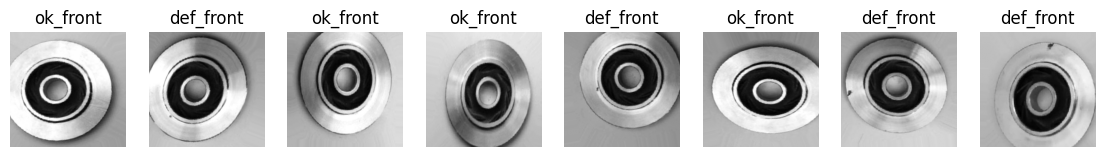

In [9]:
def show_batch(generator, n=8):
    x_batch, y_batch = next(generator)
    plt.figure(figsize=(14, 4))
    for i in range(min(n, len(x_batch))):
        plt.subplot(1, n, i+1)
        plt.imshow(x_batch[i].squeeze(), cmap="gray")
        label = "def_front" if int(y_batch[i]) == 1 else "ok_front"
        plt.title(label)
        plt.axis("off")
    plt.show()

show_batch(train_generator, n=8)

## 5. CNN 모델 생성 함수

하이퍼파라미터 조합에 따라 CNN 구조가 자동으로 생성됩니다.

In [10]:
def get_optimizer(name, learning_rate):
    name = name.lower()
    if name == "adam":
        return keras.optimizers.Adam(learning_rate=learning_rate)
    elif name == "rmsprop":
        return keras.optimizers.RMSprop(learning_rate=learning_rate)
    elif name == "sgd":
        return keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.9)
    else:
        raise ValueError(f"Unknown optimizer: {name}")


def build_cnn_model(hp):
    inputs = keras.Input(shape=(hp["img_size"], hp["img_size"], 1))
    x = inputs

    for i, filters in enumerate(hp["conv_filters"]):
        x = layers.Conv2D(
            filters=filters,
            kernel_size=(hp["kernel_size"], hp["kernel_size"]),
            padding="same",
            activation=None,
            name=f"conv_{i+1}"
        )(x)
        if hp["use_batchnorm"]:
            x = layers.BatchNormalization(name=f"bn_{i+1}")(x)
        x = layers.Activation("relu", name=f"relu_{i+1}")(x)
        x = layers.MaxPooling2D(pool_size=(2, 2), name=f"pool_{i+1}")(x)

    x = layers.Flatten()(x)
    x = layers.Dense(hp["dense_units"], activation="relu")(x)
    x = layers.Dropout(hp["dropout"])(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs, name=hp["case_name"])
    model.compile(
        optimizer=get_optimizer(hp["optimizer"], hp["learning_rate"]),
        loss="binary_crossentropy",
        metrics=["accuracy", keras.metrics.AUC(name="auc")]
    )
    return model

model = build_cnn_model(HP)
model.summary()

Model: "case_001_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 244, 244, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1 (Conv2D)                 │ (None, 244, 244, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_1 (Activation)             │ (None, 244, 244, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 122, 122, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 122, 122, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_2 (Activation)             │ (None, 122, 122, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 61, 61, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv2D)                 │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_3 (Activation)             │ (None, 61, 61, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_3 (MaxPooling2D)           │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_4 (Conv2D)                 │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_4 (Activation)             │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_4 (MaxPooling2D)           │ (None, 15, 15, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,843,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,940,481 (7.40 MB)

 Trainable params: 1,940,481 (7.40 MB)

 Non-trainable params: 0 (0.00 B)

## 6. 학습

`EarlyStopping`과 `ModelCheckpoint`를 넣어 validation loss 기준으로 가장 좋은 모델을 저장합니다.

In [11]:
OUTPUT_DIR = Path("cnn_hyperparam_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

case_name = HP["case_name"]
model_path = OUTPUT_DIR / f"{case_name}_best.keras"

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=model_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    ),
    keras.callbacks.CSVLogger(OUTPUT_DIR / f"{case_name}_history.csv"),
]

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=HP["epochs"],
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - accuracy: 0.5586 - auc: 0.5362 - loss: 0.6859
Epoch 1: val_loss improved from None to 0.62708, saving model to cnn_hyperparam_outputs/case_001_baseline_best.keras

Epoch 1: finished saving model to cnn_hyperparam_outputs/case_001_baseline_best.keras
166/166 ━━━━━━━━━━━━━━━━━━━━ 60s 301ms/step - accuracy: 0.5954 - auc: 0.6093 - loss: 0.6661 - val_accuracy: 0.6584 - val_auc: 0.7529 - val_loss: 0.6271
Epoch 2/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.6784 - auc: 0.7326 - loss: 0.6051
Epoch 2: val_loss improved from 0.62708 to 0.53481, saving model to cnn_hyperparam_outputs/case_001_baseline_best.keras

Epoch 2: finished saving model to cnn_hyperparam_outputs/case_001_baseline_best.keras
166/166 ━━━━━━━━━━━━━━━━━━━━ 43s 262ms/step - accuracy: 0.6944 - auc: 0.7534 - loss: 0.5837 - val_accuracy: 0.7504 - val_auc: 0.8127 - val_loss: 0.5348
Epoch 3/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - accuracy: 0.7398 - auc: 0

## 7. 학습 곡선 확인

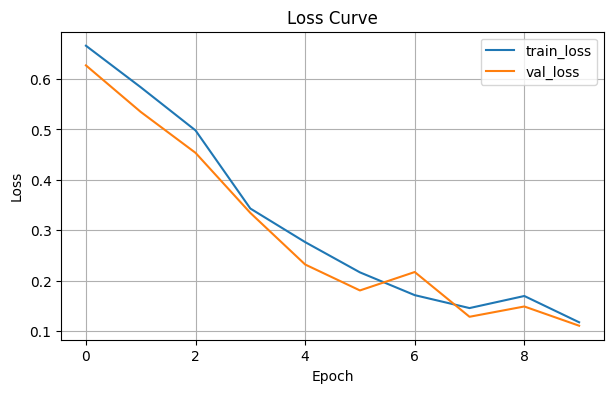

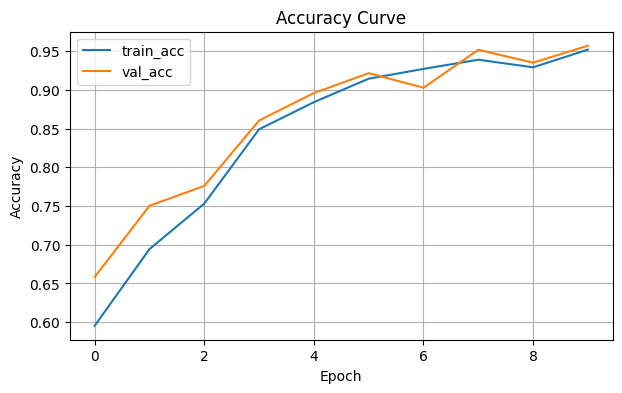

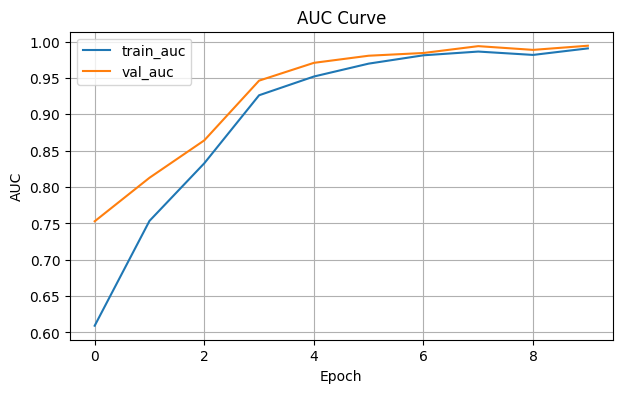

In [12]:
def plot_history(history):
    hist = history.history

    plt.figure(figsize=(7, 4))
    plt.plot(hist["loss"], label="train_loss")
    plt.plot(hist["val_loss"], label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss Curve")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(hist["accuracy"], label="train_acc")
    plt.plot(hist["val_accuracy"], label="val_acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy Curve")
    plt.legend()
    plt.grid(True)
    plt.show()

    if "auc" in hist:
        plt.figure(figsize=(7, 4))
        plt.plot(hist["auc"], label="train_auc")
        plt.plot(hist["val_auc"], label="val_auc")
        plt.xlabel("Epoch")
        plt.ylabel("AUC")
        plt.title("AUC Curve")
        plt.legend()
        plt.grid(True)
        plt.show()

plot_history(history)

## 8. Test 데이터 평가

`test_generator`는 `shuffle=False`로 두었기 때문에 예측값과 실제 라벨 순서가 일치합니다.

23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step
[[261   1]
 [ 40 413]]
Accuracy: 94.27%
Error Rate: 5.73%
Precision: 86.71%
Recall: 99.62%


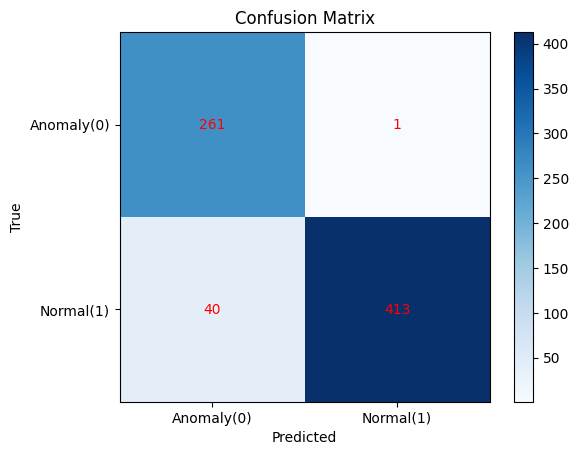

In [15]:
from sklearn.metrics import confusion_matrix
# best model 로드
best_model = keras.models.load_model(model_path)

# 확률 예측
probs = best_model.predict(test_generator).ravel()
y_true = test_generator.classes.astype(int)
y_pred = (probs >= 0.5).astype(int)

# confusion matrix
conf_mat = confusion_matrix(y_true, y_pred)

print(conf_mat)

TP = conf_mat[0][0]  # 실제 0(이상), 예측도 0 → 올바르게 이상 탐지
FN = conf_mat[0][1]  # 실제 0(이상), 예측은 1 → 이상인데 정상으로 잘못 분류
FP = conf_mat[1][0]  # 실제 1(정상), 예측은 0 → 정상인데 이상으로 잘못 분류
TN = conf_mat[1][1]  # 실제 1(정상), 예측도 1 → 올바르게 정상 탐지

accuracy = (TP + TN) / (TP + FN + FP + TN)
error_rate = (FP + FN) / (TP + FN + FP + TN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)

print(f"Accuracy: {accuracy:.2%}")  #정확도
print(f"Error Rate: {error_rate:.2%}")  #오류율
print(f"Precision: {precision:.2%}")  #정밀도
print(f"Recall: {recall:.2%}")  #재현율

# plot confusion matrix
plt.imshow(conf_mat, cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
plt.xticks([0, 1], ['Anomaly(0)', 'Normal(1)'])
plt.yticks([0, 1], ['Anomaly(0)', 'Normal(1)'])
plt.xlabel('Predicted')
plt.ylabel('True')

for i in range(2):
    for j in range(2):
        plt.text(j, i, conf_mat[i, j], ha="center", va="center", color="red")
plt.show()

In [14]:
# best model 로드
best_model = keras.models.load_model(model_path)

# 확률 예측
probs = best_model.predict(test_generator).ravel()
y_true = test_generator.classes.astype(int)
y_pred = (probs >= 0.5).astype(int)

acc = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
try:
    auc = roc_auc_score(y_true, probs)
except ValueError:
    auc = np.nan

print("Accuracy :", round(acc, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-score :", round(f1, 4))
print("AUC      :", round(auc, 4))
print("Confusion Matrix")
print(confusion_matrix(y_true, y_pred))
print("Classification Report")
print(classification_report(y_true, y_pred, target_names=["ok_front", "def_front"]))

23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 145ms/step
Accuracy : 0.9427
Precision: 0.9976
Recall   : 0.9117
F1-score : 0.9527
AUC      : 0.9971
Confusion Matrix
[[261   1]
 [ 40 413]]
Classification Report
              precision    recall  f1-score   support

    ok_front       0.87      1.00      0.93       262
   def_front       1.00      0.91      0.95       453

    accuracy                           0.94       715
   macro avg       0.93      0.95      0.94       715
weighted avg       0.95      0.94      0.94       715



## 9. 결과 저장

각 조합의 결과를 `search_results.csv`에 누적 저장합니다.  
다른 조합을 돌릴 때는 위쪽의 `CASE_IDX`만 바꿔서 다시 실행하면 됩니다.

In [16]:
result_row = {
    **HP,
    "test_accuracy": acc,
    "test_precision": precision,
    "test_recall": recall,
    "test_f1": f1,
    "test_auc": auc,
    "best_model_path": str(model_path),
}

result_path = OUTPUT_DIR / "search_results.csv"

if result_path.exists():
    result_df = pd.read_csv(result_path)
    result_df = pd.concat([result_df, pd.DataFrame([result_row])], ignore_index=True)
else:
    result_df = pd.DataFrame([result_row])

result_df.to_csv(result_path, index=False)
result_df.sort_values("test_f1", ascending=False).reset_index(drop=True)

,case_name,img_size,batch_size,conv_filters,kernel_size,dense_units,dropout,learning_rate,optimizer,epochs,use_batchnorm,augmentation,test_accuracy,test_precision,test_recall,test_f1,test_auc,best_model_path
0,case_001_baseline,244,32,"[16, 32, 64, 128]",3,64,0.2,0.001,adam,10,False,True,0.942657,0.86711,0.996183,0.95271,0.997068,cnn_hyperparam_outputs/case_001_baseline_best....


## 10. 예측 결과 샘플 시각화

정답과 예측을 같이 보여줍니다.  
`True`와 `Pred`가 다르면 오분류 샘플입니다.

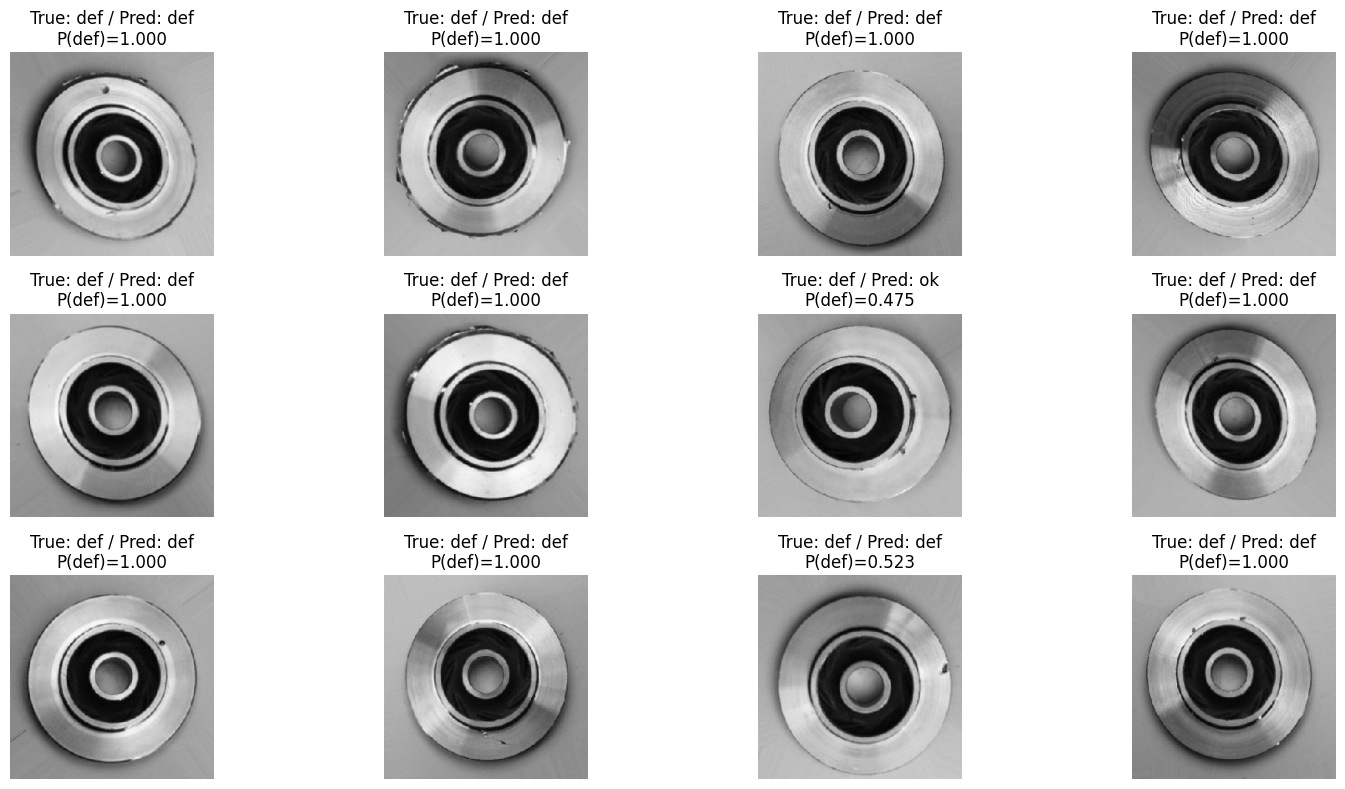

In [32]:
# test 파일 경로 추출
filepaths = np.array(test_generator.filepaths)

# 앞에서부터 일부 샘플 확인
n_show = min(12, len(filepaths))
# idxs = np.arange(n_show)
idxs = np.arange(500,512,1)

plt.figure(figsize=(16, 8))
for plot_i, idx in enumerate(idxs):
    img = keras.preprocessing.image.load_img(
        filepaths[idx],
        target_size=(IMG_SIZE, IMG_SIZE),
        color_mode="grayscale"
    )
    plt.subplot(3, 4, plot_i + 1)
    plt.imshow(img, cmap="gray")
    true_label = "def" if y_true[idx] == 1 else "ok"
    pred_label = "def" if y_pred[idx] == 1 else "ok"
    plt.title(f"True: {true_label} / Pred: {pred_label}\nP(def)={probs[idx]:.3f}")
    plt.axis("off")
plt.tight_layout()
plt.show()